# Solver comparison: Simwork vs roadrunner (SBML) vs rxode2 (nlmixr2)

Three backends claim to simulate the same Mavoglurant PBPK model. This notebook runs the
*same* structural model, with the *same* parameter values, through all three solvers and
compares the resulting `logC15` trajectories directly -- no calibration, just forward
simulation -- to check whether they actually agree.

Swept parameters: `KbBR`, `KbBO`, `KbAD`, `KbRB` (model-intrinsic, no random effect) and
`CLint` (the one PDU, with inter-individual variability -- here just varied like the others
since we're comparing the deterministic structural model, not calibrating). `KbMU` is held
fixed at its SBML default (`1.35 = exp(0.3)`) since it isn't exposed as a calibratable input
in this simplified model on the SBML side.

The `nlmixr2`/`rxode2` side can't run in-process here (this Python environment has no R), so
its results are precomputed by `rxode2_sweep.R` -- a plain rxode2 translation of the same ODE
system from `../nlmixr2_Model/Mavoglurant_convergence.R` (no `ini()`/eta, since we want the
same deterministic forward simulation as the other two, not a population fit) -- and loaded
here from `rxode2_sweep.csv`. Re-run that script (it needs R + rxode2; see its header) if you
change the parameter grid below.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vpop_calibration.api import StructuralSbml, StructuralSimwork, SimworkModelBinding

## Build the two in-process structural models

Same underlying PBPK topology, two different solvers.

In [ ]:
sbml_model = StructuralSbml(
    model_path="./CM.xml",
    inputs=["KbBR", "CLint", "KbAD", "KbBO", "KbRB", "WT", "Dose"],
    outputs=["logC15"],
)
sbml_model.rr.setIntegrator("cvode")
integ = sbml_model.rr.integrator
integ.setValue("stiff", True)
integ.setValue("relative_tolerance", 1e-6)
integ.setValue("absolute_tolerance", 1e-6)
integ.setValue("initial_time_step", 1e-6)

simwork_binding = SimworkModelBinding(
    path_to_model="../../../examples/benchmarking/Mavoglurant/cm.json",
    path_to_solving_options="../../../examples/benchmarking/Mavoglurant/sv.json",
    inputs=["KbBR", "CLint", "KbMU", "KbAD", "KbBO", "KbRB", "dose", "WT"],
    outputs=["logC15"],
    # Reuse the executable already built at the repo root (`result` symlink) instead of
    # triggering a fresh `nix build` here.
    path_to_executable="../../../result/bin/scripts.run-model-simple",
)
simwork_model = StructuralSimwork(model=simwork_binding)

## Parameter sweep

For each of the 5 parameters, hold the other 4 at their prior/baseline value and vary that
one parameter by x0.5 and x2 around baseline (plus the shared baseline itself, deduplicated).

**This exact grid (baseline values, factors, WT, Dose, time grid) must match what
`rxode2_sweep.R` uses** -- they were written together, but if you change one, change both.


In [ ]:
BASELINE = {
    "KbBR": np.exp(1.1),
    "CLint": np.exp(7.6),
    "KbAD": np.exp(2),
    "KbBO": np.exp(0.03),
    "KbRB": np.exp(0.3),
}
KBMU = np.exp(0.3)  # held fixed, matches CM.xml's default
WT = 82.1  # dataset median
DOSE = 50.0
FACTORS = [0.5, 1.0, 2.0]

rows = []
for pname in BASELINE:
    for factor in FACTORS:
        row = dict(BASELINE)
        row[pname] = BASELINE[pname] * factor
        row["id"] = f"{pname}_x{factor:g}"
        row["swept_param"] = pname
        row["factor"] = factor
        rows.append(row)

vpop = pd.DataFrame(rows).drop_duplicates(subset=list(BASELINE)).reset_index(drop=True)
print(f"{len(vpop)} distinct parameter combinations")
vpop

11 distinct parameter combinations


,KbBR,CLint,KbAD,KbBO,KbRB,id,swept_param,factor
0,1.502083,1998.195895,7.389056,1.030455,1.349859,KbBR_x0.5,KbBR,0.5
1,3.004166,1998.195895,7.389056,1.030455,1.349859,KbBR_x1,KbBR,1.0
2,6.008332,1998.195895,7.389056,1.030455,1.349859,KbBR_x2,KbBR,2.0
3,3.004166,999.097948,7.389056,1.030455,1.349859,CLint_x0.5,CLint,0.5
4,3.004166,3996.391790,7.389056,1.030455,1.349859,CLint_x2,CLint,2.0
5,3.004166,1998.195895,3.694528,1.030455,1.349859,KbAD_x0.5,KbAD,0.5
6,3.004166,1998.195895,14.778112,1.030455,1.349859,KbAD_x2,KbAD,2.0
7,3.004166,1998.195895,7.389056,0.515227,1.349859,KbBO_x0.5,KbBO,0.5
8,3.004166,1998.195895,7.389056,2.060909,1.349859,KbBO_x2,KbBO,2.0
9,3.004166,1998.195895,7.389056,1.030455,0.674929,KbRB_x0.5,KbRB,0.5


## Run the two in-process solvers, and load the precomputed rxode2 results

In [ ]:
time_h = np.linspace(0.1, 48, 60)
time_s = time_h * 3600
time_idx = np.arange(len(time_h))

obs_template = pd.concat(
    [
        pd.DataFrame(
            {
                "id": pid,
                "time": time_s,
                "time_idx": time_idx,
                "output_name": "logC15",
                "protocol_arm": "identity",
                "value": 0.0,
            }
        )
        for pid in vpop["id"]
    ],
    ignore_index=True,
)

vpop_sbml = vpop.copy()
vpop_sbml["WT"] = WT
vpop_sbml["Dose"] = DOSE
vpop_sbml["protocol_arm"] = "identity"
out_sbml = sbml_model.simulate_from_df(vpop_sbml, obs_template.copy())
out_sbml["solver"] = "roadrunner (SBML)"
out_sbml["concentration"] = np.exp(out_sbml["predicted_value"])

vpop_simwork = vpop.copy()
vpop_simwork["KbMU"] = KBMU
vpop_simwork["dose"] = DOSE
vpop_simwork["WT"] = WT
vpop_simwork["protocol_arm"] = "identity"
out_simwork = simwork_model.simulate_from_df(vpop_simwork, obs_template.copy())
out_simwork["solver"] = "Simwork"
out_simwork["concentration"] = np.exp(out_simwork["predicted_value"])

# rxode2_sweep.R's write.csv() only preserves ~15 significant digits for its time_h column,
# vs Python's full float64 (~17) -- joining on that raw float later would silently drop
# almost every row past the first couple of time points. Join on time_idx instead (both
# sides walk the same 60-point grid in the same order) and take time_h from the Python side,
# which is authoritative here.
out_rxode2 = pd.read_csv("rxode2_sweep.csv").drop(
    columns="time_h"
)  # produced by rxode2_sweep.R

comparison = pd.concat(
    [
        out_sbml[["id", "time_idx", "concentration", "solver"]],
        out_simwork[["id", "time_idx", "concentration", "solver"]],
        out_rxode2[["id", "time_idx", "concentration", "solver"]],
    ],
    ignore_index=True,
)
comparison["time_h"] = time_h[comparison["time_idx"]]
comparison = comparison.merge(
    vpop[["id", "swept_param", "factor"]], on="id", how="left"
)
SOLVERS = ["roadrunner (SBML)", "Simwork", "nlmixr2/rxode2"]
comparison.head()

,id,time_idx,concentration,solver,time_h,swept_param,factor
0,KbBR_x0.5,0,18475.407917,roadrunner (SBML),0.100000,KbBR,0.5
1,KbBR_x0.5,1,345.780168,roadrunner (SBML),0.911864,KbBR,0.5
2,KbBR_x0.5,2,204.392838,roadrunner (SBML),1.723729,KbBR,0.5
3,KbBR_x0.5,3,134.145202,roadrunner (SBML),2.535593,KbBR,0.5
4,KbBR_x0.5,4,93.168274,roadrunner (SBML),3.347458,KbBR,0.5


## Curve-by-curve comparison

One panel per swept parameter, one line style per factor, one color per solver. Each
panel uses its own y-axis (not shared) -- `CLint` and `KbAD` change `logC15` by 1-2 orders
of magnitude across this sweep (CLint is the direct hepatic-clearance term; KbAD governs
adipose, the largest-volume swept compartment and the dominant slow/terminal-phase
reservoir for this lipophilic drug), while `KbBR`/`KbBO`/`KbRB` (brain, bones, rest-of-body)
only move it by about 4-7%. A shared axis across all five panels would make the latter three
look flat/unaffected even though they do have a real, non-zero effect.


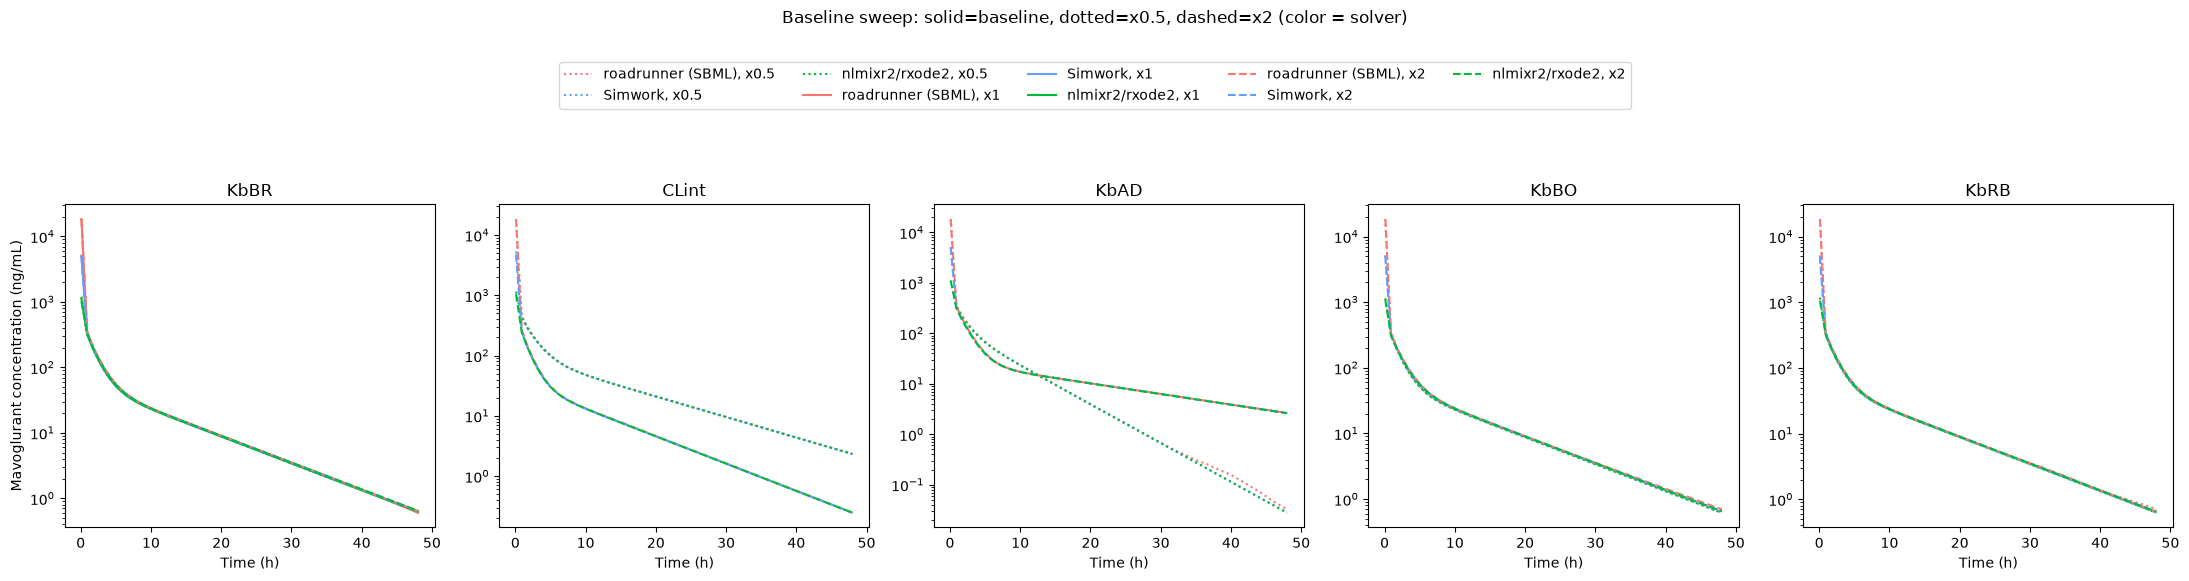

In [ ]:
palette = {
    "roadrunner (SBML)": "#F8766D",
    "Simwork": "#619CFF",
    "nlmixr2/rxode2": "#00BA38",
}
linestyles = {0.5: ":", 1.0: "-", 2.0: "--"}

# sharey=False: CLint and KbAD dominate the sensitivity of logC15 by 1-2 orders of
# magnitude over KbBR/KbBO/KbRB (see the markdown note above) -- a shared log-scale axis
# spanning the full ~18000-to-0.03 concentration range would flatten the smaller-effect
# panels into what looks like "no effect".
fig, axes = plt.subplots(1, len(BASELINE), figsize=(22, 4.5), sharey=False)
for ax, pname in zip(axes, BASELINE):
    df_p = comparison[comparison["swept_param"] == pname]
    for factor in FACTORS:
        df_f = df_p[df_p["factor"] == factor]
        for solver, color in palette.items():
            df_s = df_f[df_f["solver"] == solver].sort_values("time_h")
            if df_s.empty:
                continue
            ax.plot(
                df_s["time_h"],
                df_s["concentration"],
                color=color,
                linestyle=linestyles[factor],
                label=f"{solver}, x{factor:g}",
            )
    ax.set_yscale("log")
    ax.set_title(pname)
    ax.set_xlabel("Time (h)")
axes[0].set_ylabel("Mavoglurant concentration (ng/mL)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=5)
fig.suptitle(
    "Baseline sweep: solid=baseline, dotted=x0.5, dashed=x2 (color = solver)", y=1.28
)
fig.tight_layout()
plt.show()

## Quantifying the discrepancy

With three solvers there are three pairwise relative differences per parameter
combination and time point: `|A - B| / |B|` for each unordered pair. We also report a
single `spread` metric, `(max - min) / median` across the three solvers at each point, as
an overall "how much do these three disagree here" summary.


In [ ]:
wide = comparison.pivot_table(
    index=["id", "swept_param", "factor", "time_idx", "time_h"],
    columns="solver",
    values="concentration",
).reset_index()

pairs = [
    ("roadrunner (SBML)", "Simwork"),
    ("roadrunner (SBML)", "nlmixr2/rxode2"),
    ("Simwork", "nlmixr2/rxode2"),
]
for a, b in pairs:
    wide[f"reldiff_{a}_vs_{b}"] = (wide[a] - wide[b]).abs() / wide[b].abs()

solver_vals = wide[SOLVERS].to_numpy()
wide["spread"] = (solver_vals.max(axis=1) - solver_vals.min(axis=1)) / np.median(
    solver_vals, axis=1
)

reldiff_cols = [f"reldiff_{a}_vs_{b}" for a, b in pairs]
summary = (
    wide.groupby(["swept_param", "factor"])[reldiff_cols + ["spread"]]
    .agg(["mean", "max"])
    .sort_values(("spread", "max"), ascending=False)
)
summary

solver             reldiff_roadrunner (SBML)_vs_Simwork            \
                                                   mean       max   
swept_param factor                                                  
CLint       2.0                                0.060081  2.865307   
KbBR        2.0                                0.058125  2.735314   
KbRB        2.0                                0.058621  2.717254   
KbBO        2.0                                0.069861  2.688458   
KbAD        2.0                                0.054276  2.627753   
KbBR        1.0                                0.058082  2.622462   
KbAD        0.5                                0.132017  2.612239   
KbBR        0.5                                0.054384  2.603145   
KbRB        0.5                                0.071667  2.583046   
KbBO        0.5                                0.071239  2.557309   
CLint       0.5                                0.051936  2.440488   

solver             reldiff_roadrunner (SBML)_vs_nlmixr2/rxode2             \
                                                          mean        max   
swept_param factor                                                          
CLint       2.0                                       0.290015  16.651804   
KbBR        2.0                                       0.300995  17.300258   
KbRB        2.0                                       0.289241  16.547386   
KbBO        2.0                                       0.291889  16.001559   
KbAD        2.0                                       0.271539  15.654401   
KbBR        1.0                                       0.275097  15.634686   
KbAD        0.5                                       0.348515  15.595805   
KbBR        0.5                                       0.249951  14.328624   
KbRB        0.5                                       0.273700  14.696075   
KbBO        0.5                                       0.280330  15.092927   
CLint       0.5                                       0.261715  15.020037   

solver             reldiff_Simwork_vs_nlmixr2/rxode2              spread  \
                                                mean       max      mean   
swept_param factor                                                         
CLint       2.0                             0.059597  3.566727  0.073248   
KbBR        2.0                             0.065102  3.899256  0.071504   
KbRB        2.0                             0.062122  3.720524  0.071869   
KbBO        2.0                             0.060293  3.609395  0.083047   
KbAD        2.0                             0.059991  3.590832  0.067455   
KbBR        1.0                             0.060005  3.592094  0.071256   
KbAD        0.5                             0.060045  3.594327  0.145173   
KbBR        0.5                             0.054372  3.254234  0.067267   
KbRB        0.5                             0.056485  3.380652  0.084670   
KbBO        0.5                             0.058887  3.523904  0.084375   
CLint       0.5                             0.061054  3.656326  0.065137   

solver                        
                         max  
swept_param factor            
CLint       2.0     3.646332  
KbBR        2.0     3.531201  
KbRB        2.0     3.505413  
KbBO        2.0     3.471509  
KbAD        2.0     3.409927  
KbBR        1.0     3.404696  
KbAD        0.5     3.394579  
KbBR        0.5     3.368085  
KbRB        0.5     3.354769  
KbBO        0.5     3.336261  
CLint       0.5     3.225727

In [ ]:
worst = wide.sort_values("spread", ascending=False).head(15)
worst[["id", "time_h", *SOLVERS, "spread"]]

solver,id,time_h,roadrunner (SBML),Simwork,nlmixr2/rxode2,spread
60,CLint_x2,0.100000,18475.407917,4779.803319,1046.658353,3.646332
480,KbBR_x2,0.100000,18475.407917,4946.146397,1009.570905,3.531201
600,KbRB_x2,0.100000,18475.407917,4970.176271,1052.886605,3.505413
300,KbBO_x2,0.100000,18475.407917,5008.979221,1086.689052,3.471509
180,KbAD_x2,0.100000,18475.407917,5092.797200,1109.340862,3.409927
420,KbBR_x1,0.100000,18475.407917,5100.235452,1110.655632,3.404696
120,KbAD_x0.5,0.100000,18475.407917,5114.669448,1113.257685,3.394579
360,KbBR_x0.5,0.100000,18475.407917,5127.577637,1205.288052,3.368085
540,KbRB_x0.5,0.100000,18475.407917,5156.341659,1177.071864,3.354769
240,KbBO_x0.5,0.100000,18475.407917,5193.646708,1148.045239,3.336261


## Disagreement over time

Averaged (and maxed) across all parameter combinations, to see whether the
discrepancy is concentrated at particular points in the time course (e.g. right after
the dose) rather than being a uniform offset.


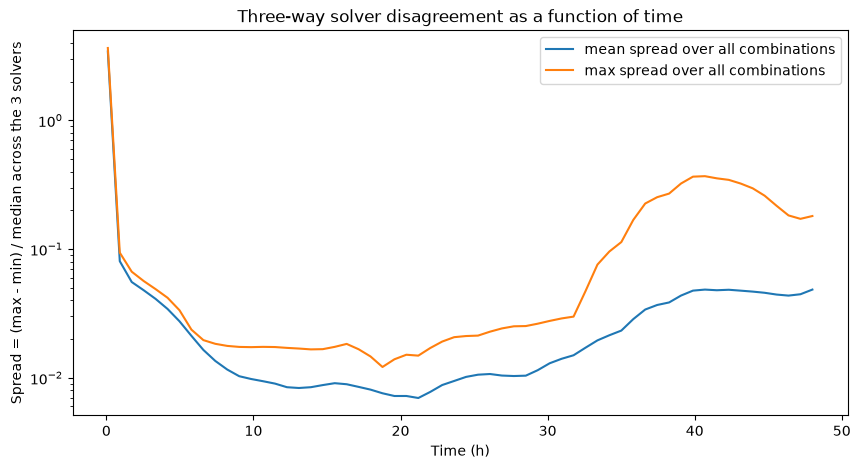

In [ ]:
by_time = wide.groupby("time_h")["spread"].agg(["mean", "max"]).reset_index()

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(by_time["time_h"], by_time["mean"], label="mean spread over all combinations")
ax2.plot(by_time["time_h"], by_time["max"], label="max spread over all combinations")
ax2.set_xlabel("Time (h)")
ax2.set_ylabel("Spread = (max - min) / median across the 3 solvers")
ax2.set_yscale("log")
ax2.legend()
ax2.set_title("Three-way solver disagreement as a function of time")
plt.show()